# Minería de Datos — Semana 2, Clase 2
## Laboratorio: Preprocesamiento de Datos con scikit-learn

**Institución:** Politécnico Malvinas Argentinas
**Tecnicatura en Informática — 2026**

---

### Objetivos del laboratorio
- **APLICAR** LabelEncoder y OneHotEncoder a variables categóricas del Titanic
- **COMPARAR** StandardScaler vs MinMaxScaler y visualizar el efecto sobre la distribución
- **CONSTRUIR** un pipeline completo con ColumnTransformer, imputación, encoding y Logistic Regression
- **VERIFICAR** la ausencia de data leakage inspeccionando los estadísticos del pipeline
- **EVALUAR** el modelo con accuracy, classification_report y matriz de confusión

### Flujo del laboratorio
1. Setup e importaciones
2. Carga y diagnóstico del dataset Titanic
3. Definir features y hacer train_test_split
4. Demo: Encoding (LabelEncoder + OneHotEncoder)
5. Demo: Scaling (StandardScaler vs MinMaxScaler)
6. Construir Pipeline completo
7. Evaluar resultados
8. Verificar ausencia de leakage
9. ☑ Actividades guiadas (TODO)
10. 🏆 Actividad autónoma


## Celda 1 — Importar librerías y verificar entorno

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import (
    StandardScaler, MinMaxScaler, RobustScaler,
    OneHotEncoder, LabelEncoder
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
import warnings
warnings.filterwarnings('ignore')

print("Librerías importadas correctamente ✓")
print(f"  pandas   {pd.__version__}")
print(f"  sklearn  ", end="")
import sklearn; print(sklearn.__version__)


Librerías importadas correctamente ✓
  pandas   2.3.3
  sklearn  1.7.2


## Celda 2 — Cargar el dataset Titanic

Usamos `seaborn.load_dataset('titanic')` para cargar el dataset directamente sin necesidad de subir archivos.
El dataset tiene 891 filas y 15 columnas. Vamos a usar solo un subconjunto.

In [40]:
# Cargar Titanic desde seaborn (no se necesita subir archivos)
df_raw = sns.load_dataset('titanic')

print(f"Shape original: {df_raw.shape}")
print(f"Columnas: {list(df_raw.columns)}")
print()
df_raw.head(3)


Shape original: (891, 15)
Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']



,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


## Celda 3 — Diagnóstico: tipos y valores nulos

Antes de cualquier transformación, necesitamos entender los datos:
- ¿Qué tipo tiene cada columna?
- ¿Cuántos nulos hay?
- ¿Hay categorías con cardinalidad alta?

In [41]:
# Tipos de datos
print("Tipos de datos:")
print(df_raw.dtypes)
print()

# Porcentaje de nulos por columna
nulos = df_raw.isnull().sum()
pct_nulos = (nulos / len(df_raw) * 100).round(1)
diagnostico = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos
}).sort_values('Porcentaje (%)', ascending=False)
print("Diagnóstico de valores faltantes:")
print(diagnostico[diagnostico['Nulos'] > 0])


Tipos de datos:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

Diagnóstico de valores faltantes:
             Nulos  Porcentaje (%)
deck           688            77.2
age            177            19.9
embarked         2             0.2
embark_town      2             0.2


> **Observación:** `deck` (equivalente a Cabin) tiene ~77% de nulos → la descartamos.  
> `age` tiene ~20% → imputamos con la mediana.  
> `embarked` tiene 2 nulos → imputamos con el valor más frecuente.

## Celda 4 — Heatmap de correlaciones y distribuciones de variables clave

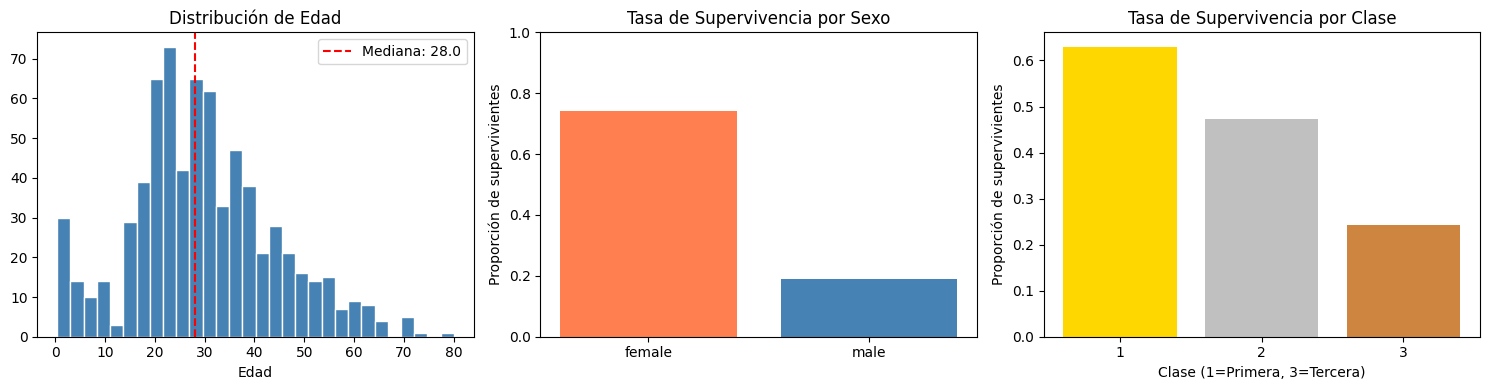

In [42]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribución de edad
axes[0].hist(df_raw['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].axvline(df_raw['age'].median(), color='red', linestyle='--', label=f'Mediana: {df_raw["age"].median():.1f}')
axes[0].legend()

# Supervivencia por sexo
survived_sex = df_raw.groupby('sex')['survived'].mean()
axes[1].bar(survived_sex.index, survived_sex.values, color=['coral','steelblue'])
axes[1].set_title('Tasa de Supervivencia por Sexo')
axes[1].set_ylabel('Proporción de supervivientes')
axes[1].set_ylim(0, 1)

# Supervivencia por clase
survived_pclass = df_raw.groupby('pclass')['survived'].mean()
axes[2].bar(survived_pclass.index.astype(str), survived_pclass.values, color=['gold','silver','peru'])
axes[2].set_title('Tasa de Supervivencia por Clase')
axes[2].set_ylabel('Proporción de supervivientes')
axes[2].set_xlabel('Clase (1=Primera, 3=Tercera)')

plt.tight_layout()
plt.show()


## Celda 5 — Seleccionar columnas y hacer train_test_split

**⚠ REGLA FUNDAMENTAL:** El `train_test_split` se hace ANTES de cualquier preprocesamiento.
Nunca calcular estadísticas (medias, medianas, modas) con el dataset completo antes de dividir.

In [43]:
# Seleccionar columnas útiles
# Descartamos: name, ticket, cabin/deck (77% nulos), embarked_town, alive, alone, adult_male, who, class
cols_usar = ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df_raw[cols_usar].copy()

print(f"Dataset reducido: {df.shape}")
print(f"Columnas: {list(df.columns)}")
print()

# Separar features y target
X = df.drop('survived', axis=1)
y = df['survived']

# PRIMERO: train_test_split con stratify
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # preservar proporción de clases
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"Proporción survived en train: {y_train.mean():.3f}")
print(f"Proporción survived en test:  {y_test.mean():.3f}")
print("(Deben ser similares gracias a stratify=y)")


Dataset reducido: (891, 8)
Columnas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

X_train: (712, 7)   X_test: (179, 7)
Proporción survived en train: 0.383
Proporción survived en test:  0.385
(Deben ser similares gracias a stratify=y)


## Celda 6 — Demo: LabelEncoder en columna 'sex'

Primero hacemos esto manualmente para entender cómo funciona.
Luego el pipeline lo va a hacer automáticamente.

In [44]:
# LabelEncoder para variable binaria 'sex'
le = LabelEncoder()

# Fit SOLO con X_train
le.fit(X_train['sex'])

print("Clases aprendidas:", le.classes_)
print("→ female=0, male=1 (orden alfabético)")
print()

# Ver la transformación
sex_encoded = le.transform(X_train['sex'])
print("Primeros 10 valores originales:", X_train['sex'].values[:10])
print("Primeros 10 valores codificados:", sex_encoded[:10])
print()

# Conteo
print("Distribución:")
print(pd.Series(sex_encoded).value_counts().rename({0:'female (0)', 1:'male (1)'}))


Clases aprendidas: ['female' 'male']
→ female=0, male=1 (orden alfabético)

Primeros 10 valores originales: ['male' 'male' 'male' 'female' 'female' 'male' 'male' 'male' 'male'
 'female']
Primeros 10 valores codificados: [1 1 1 0 0 1 1 1 1 0]

Distribución:
male (1)      459
female (0)    253
Name: count, dtype: int64


## Celda 7 — Demo: OneHotEncoder en columna 'embarked'

`embarked` tiene 3 categorías: C (Cherbourg), Q (Queenstown), S (Southampton).
Con `drop='first'` generamos solo 2 columnas (evitando multicolinealidad).

In [45]:
# OneHotEncoder para 'embarked'
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Primero imputar los 2 nulos (moda = 'S')
embarked_train = X_train[['embarked']].fillna('S')

# Fit SOLO con X_train
ohe.fit(embarked_train)

print("Categorías aprendidas:", ohe.categories_)
print("Columnas generadas (drop='first'):", ohe.get_feature_names_out())
print()

# Transformar
embarked_enc = ohe.transform(embarked_train)
print("Primeras 8 filas (columnas: embarked_Q, embarked_S):")
print(pd.DataFrame(embarked_enc,
                   columns=ohe.get_feature_names_out()).head(8))
print()
print("Interpretación:")
print("  Q=0, S=0 → embarcó en C (Cherbourg) — implícito")
print("  Q=1, S=0 → embarcó en Q (Queenstown)")
print("  Q=0, S=1 → embarcó en S (Southampton)")


Categorías aprendidas: [array(['C', 'Q', 'S'], dtype=object)]
Columnas generadas (drop='first'): ['embarked_Q' 'embarked_S']

Primeras 8 filas (columnas: embarked_Q, embarked_S):
   embarked_Q  embarked_S
0         0.0         1.0
1         0.0         1.0
2         0.0         1.0
3         0.0         1.0
4         0.0         1.0
5         0.0         1.0
6         0.0         1.0
7         0.0         0.0

Interpretación:
  Q=0, S=0 → embarcó en C (Cherbourg) — implícito
  Q=1, S=0 → embarcó en Q (Queenstown)
  Q=0, S=1 → embarcó en S (Southampton)


## Celda 8 — Demo: StandardScaler vs MinMaxScaler

Comparamos los dos scalers principales y visualizamos su efecto sobre la distribución de `age`.

Age original  → media: 29.56, std: 13.03
StandardScaler→ media: 0.0000, std: 1.0000
MinMaxScaler  → min:   0.0000, max: 1.0000



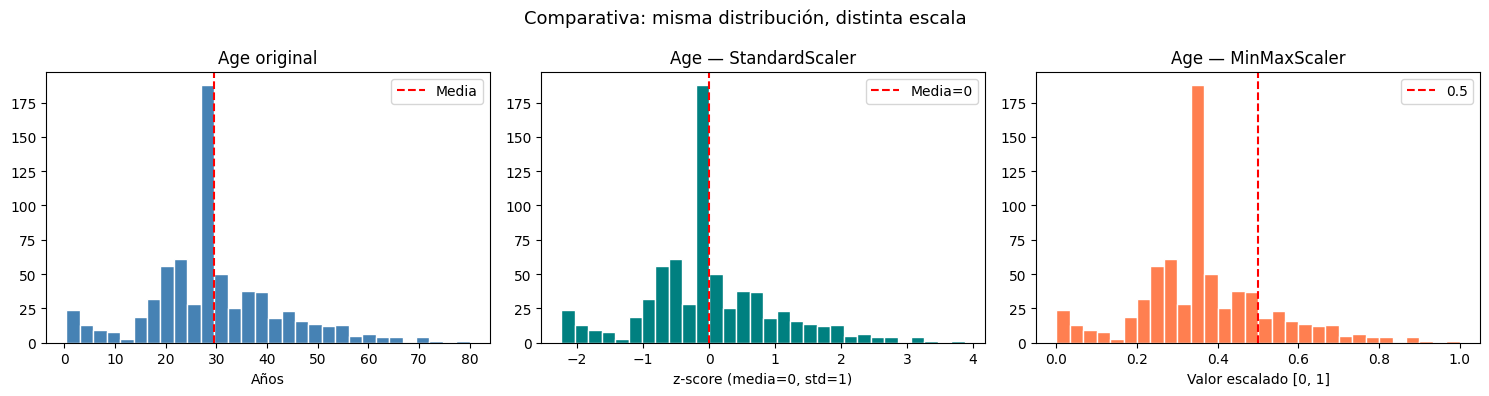

In [46]:
# Extraer columna age (sin NaN para el demo manual)
age_train = X_train['age'].copy()
# Para el demo manual, imputamos con la mediana
age_train_filled = age_train.fillna(age_train.median())

# StandardScaler
ss = StandardScaler()
age_std = ss.fit_transform(age_train_filled.values.reshape(-1, 1)).flatten()

# MinMaxScaler
mm = MinMaxScaler()
age_mm = mm.fit_transform(age_train_filled.values.reshape(-1, 1)).flatten()

print(f"Age original  → media: {age_train_filled.mean():.2f}, std: {age_train_filled.std():.2f}")
print(f"StandardScaler→ media: {age_std.mean():.4f}, std: {age_std.std():.4f}")
print(f"MinMaxScaler  → min:   {age_mm.min():.4f}, max: {age_mm.max():.4f}")
print()

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(age_train_filled, bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Age original')
axes[0].set_xlabel('Años')
axes[0].axvline(age_train_filled.mean(), color='red', linestyle='--', label='Media')
axes[0].legend()

axes[1].hist(age_std, bins=30, color='teal', edgecolor='white')
axes[1].set_title('Age — StandardScaler')
axes[1].set_xlabel('z-score (media=0, std=1)')
axes[1].axvline(0, color='red', linestyle='--', label='Media=0')
axes[1].legend()

axes[2].hist(age_mm, bins=30, color='coral', edgecolor='white')
axes[2].set_title('Age — MinMaxScaler')
axes[2].set_xlabel('Valor escalado [0, 1]')
axes[2].axvline(0.5, color='red', linestyle='--', label='0.5')
axes[2].legend()

plt.suptitle('Comparativa: misma distribución, distinta escala', fontsize=13)
plt.tight_layout()
plt.show()


## Celda 9 — Construir el Pipeline completo

Ahora ensamblamos todo en un pipeline que:
1. Imputa y escala las columnas numéricas
2. Imputa y codifica las columnas categóricas
3. Entrena una Regresión Logística

In [47]:
# Definir qué columnas van a cada transformador
num_cols = ['age', 'fare', 'sibsp', 'parch']
cat_cols = ['sex', 'embarked', 'pclass']

# Pipeline para columnas NUMÉRICAS: imputar → escalar
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Pipeline para columnas CATEGÓRICAS: imputar → OneHotEncoder
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combinar ambos con ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('cat', cat_pipe, cat_cols)
])

# Pipeline final: preprocesador + modelo
pipeline = Pipeline([
    ('prep',  preprocessor),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline construido:")
print(pipeline)


Pipeline construido:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'fare', 'sibsp',
                                                   'parch']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first'

## Celda 10 — Entrenar el pipeline y evaluar resultados

Una sola llamada `.fit()` ejecuta todos los pasos en orden — imputación, encoding, scaling y entrenamiento del modelo.

In [48]:
# Entrenar el pipeline completo (solo con X_train)
pipeline.fit(X_train, y_train)
print("Pipeline entrenado ✓")
print()

# Accuracy en train y test
acc_train = pipeline.score(X_train, y_train)
acc_test  = pipeline.score(X_test,  y_test)
print(f"Accuracy en TRAIN: {acc_train:.4f}  ({acc_train*100:.1f}%)")
print(f"Accuracy en TEST:  {acc_test:.4f}  ({acc_test*100:.1f}%)")
print()

# Reporte detallado
y_pred = pipeline.predict(X_test)
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['No sobrevivió (0)', 'Sobrevivió (1)']
))


Pipeline entrenado ✓

Accuracy en TRAIN: 0.8104  (81.0%)
Accuracy en TEST:  0.7989  (79.9%)

Classification Report:
                   precision    recall  f1-score   support

No sobrevivió (0)       0.81      0.88      0.84       110
   Sobrevivió (1)       0.78      0.67      0.72        69

         accuracy                           0.80       179
        macro avg       0.79      0.77      0.78       179
     weighted avg       0.80      0.80      0.80       179



## Celda 11 — Visualizar: Matriz de confusión y distribución de probabilidades

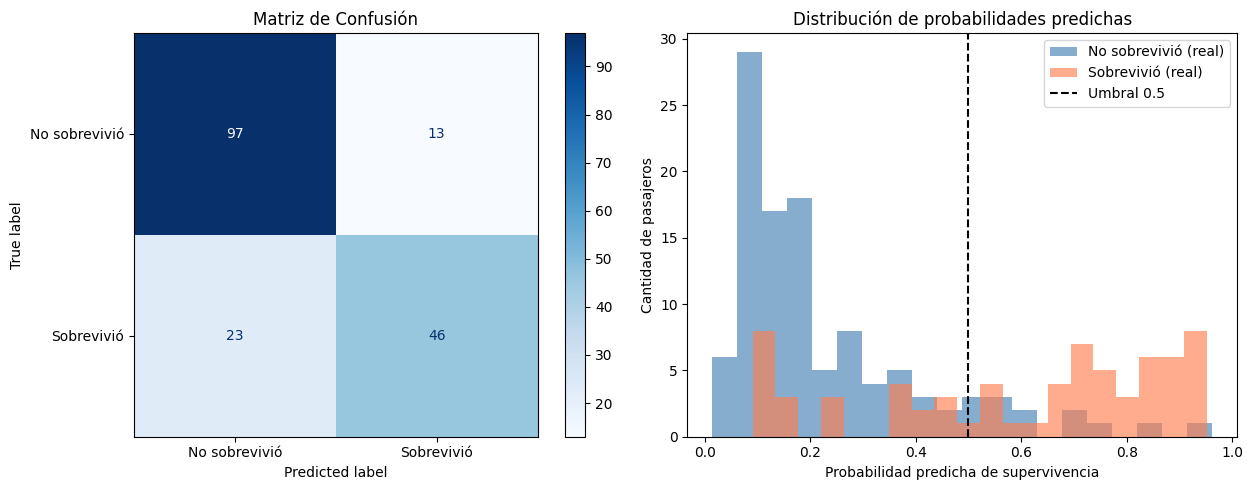

Total predicciones correctas:   143 / 179
Falsos positivos (FP): predijo sobrevivió, no sobrevivió: 13
Falsos negativos (FN): predijo no, sí sobrevivió:         23


In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusión
ConfusionMatrixDisplay.from_estimator(
    pipeline, X_test, y_test,
    display_labels=['No sobrevivió', 'Sobrevivió'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión')

# Distribución de probabilidades predichas
probs = pipeline.predict_proba(X_test)[:, 1]
axes[1].hist(probs[y_test == 0], bins=20, alpha=0.65,
             color='steelblue', label='No sobrevivió (real)')
axes[1].hist(probs[y_test == 1], bins=20, alpha=0.65,
             color='coral', label='Sobrevivió (real)')
axes[1].axvline(0.5, color='black', linestyle='--', label='Umbral 0.5')
axes[1].set_xlabel('Probabilidad predicha de supervivencia')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].set_title('Distribución de probabilidades predichas')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Total predicciones correctas:   {(y_pred == y_test).sum()} / {len(y_test)}")
print(f"Falsos positivos (FP): predijo sobrevivió, no sobrevivió: {((y_pred==1)&(y_test==0)).sum()}")
print(f"Falsos negativos (FN): predijo no, sí sobrevivió:         {((y_pred==0)&(y_test==1)).sum()}")


## Celda 12 — Verificar que no hay Data Leakage

Inspeccionamos los estadísticos que el pipeline aprendió y confirmamos que son los del conjunto de entrenamiento.

In [50]:
# Acceder a los componentes internos del pipeline
preprocessor_fit = pipeline.named_steps['prep']
num_transformer  = preprocessor_fit.named_transformers_['num']
imputer          = num_transformer.named_steps['imputer']
scaler           = num_transformer.named_steps['scaler']

print("=== Verificación de estadísticos aprendidos ===")
print()
print(f"Columnas numéricas: {num_cols}")
print()
print(f"Medianas aprendidas por el imputador: {imputer.statistics_.round(3)}")
print(f"Medianas reales de X_train:           {X_train[num_cols].median().values.round(3)}")
print()
print(f"Medias aprendidas por el scaler:      {scaler.mean_.round(3)}")
print(f"Medias reales de X_train:             {X_train[num_cols].mean().values.round(3)}")
print()
# Comparar con las del dataset completo (para demostrar que son distintas)
print("Comparación con el dataset COMPLETO (evidencia de no-leakage):")
print(f"Mediana de 'age' en X_train: {X_train['age'].median():.2f}")
print(f"Mediana de 'age' en df total: {df['age'].median():.2f}")
print()
if abs(X_train['age'].median() - df['age'].median()) > 0.1:
    print("✓ Son distintas → el pipeline aprendió solo de X_train (sin leakage)")
else:
    print("⚠ Son muy similares en este caso (dataset balanceado), pero el proceso es correcto")


=== Verificación de estadísticos aprendidos ===

Columnas numéricas: ['age', 'fare', 'sibsp', 'parch']

Medianas aprendidas por el imputador: [28.5   14.454  0.     0.   ]
Medianas reales de X_train:           [28.5   14.454  0.     0.   ]

Medias aprendidas por el scaler:      [29.556 31.82   0.493  0.39 ]
Medias reales de X_train:             [29.808 31.82   0.493  0.39 ]

Comparación con el dataset COMPLETO (evidencia de no-leakage):
Mediana de 'age' en X_train: 28.50
Mediana de 'age' en df total: 28.00

✓ Son distintas → el pipeline aprendió solo de X_train (sin leakage)


---
## ☑ Actividades Guiadas — TODO

Estas celdas tienen `# TODO: ` para que completes el código.
Las soluciones están comentadas más abajo — ¡intentalo solo primero!

---
### Actividad 1 ★ Básico — Comparar estrategias de imputación en 'age'

Comparar `strategy='mean'` vs `strategy='median'` y ver la diferencia en la distribución.

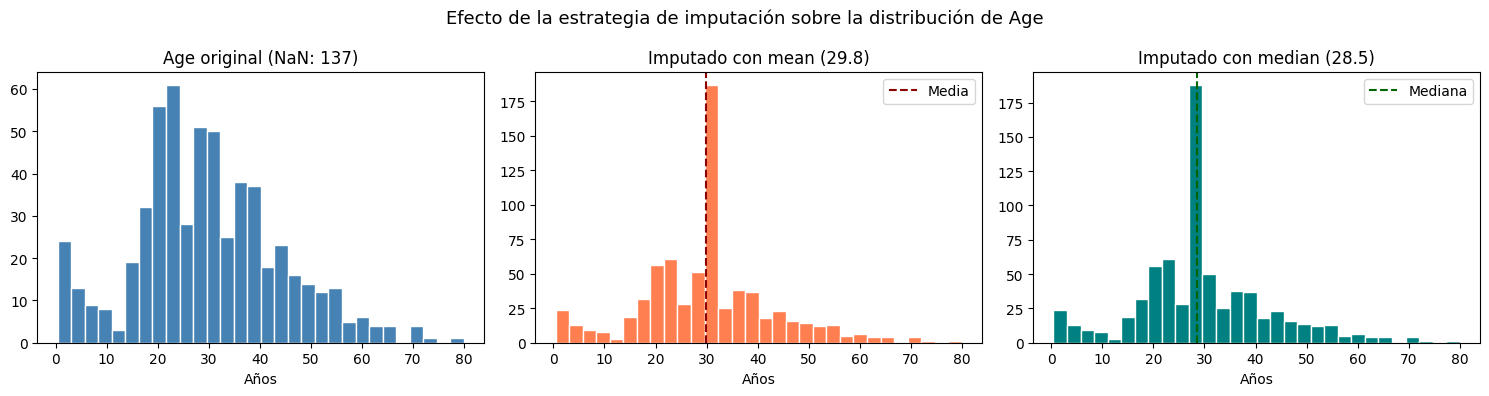

Media del imputador  mean:    29.81
Mediana del imputador median: 28.50

Observación: ambos crean un 'pico' artificial en el valor imputado.
La mediana es menos sensible a outliers que la media.
Diferencia mean-median: 1.31 años


In [51]:
# Actividad 1: Comparar estrategias de imputación mean vs median en 'age'

# 1a. Crear dos imputadores
imp_mean   = SimpleImputer(strategy='mean')
imp_median = SimpleImputer(strategy='median')

# 1b. Fit SOLO con X_train[['age']]
imp_mean.fit(X_train[['age']])
imp_median.fit(X_train[['age']])

# 1c. Transformar
age_mean   = imp_mean.transform(X_train[['age']]).flatten()
age_median = imp_median.transform(X_train[['age']]).flatten()

# 1d. Graficar comparativa
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_train['age'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0].set_title(f'Age original (NaN: {X_train["age"].isna().sum()})')
axes[0].set_xlabel('Años')

axes[1].hist(age_mean, bins=30, color='coral', edgecolor='white')
axes[1].set_title(f'Imputado con mean ({imp_mean.statistics_[0]:.1f})')
axes[1].set_xlabel('Años')
axes[1].axvline(imp_mean.statistics_[0], color='darkred', linestyle='--', label='Media')
axes[1].legend()

axes[2].hist(age_median, bins=30, color='teal', edgecolor='white')
axes[2].set_title(f'Imputado con median ({imp_median.statistics_[0]:.1f})')
axes[2].set_xlabel('Años')
axes[2].axvline(imp_median.statistics_[0], color='darkgreen', linestyle='--', label='Mediana')
axes[2].legend()

plt.suptitle('Efecto de la estrategia de imputación sobre la distribución de Age', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Media del imputador  mean:    {imp_mean.statistics_[0]:.2f}")
print(f"Mediana del imputador median: {imp_median.statistics_[0]:.2f}")
print()
print("Observación: ambos crean un 'pico' artificial en el valor imputado.")
print("La mediana es menos sensible a outliers que la media.")
print(f"Diferencia mean-median: {imp_mean.statistics_[0] - imp_median.statistics_[0]:.2f} años")


### Actividad 2 ★★ Medio — Comparar StandardScaler vs MinMaxScaler en el pipeline completo

In [52]:
# Actividad 2: Comparar StandardScaler vs MinMaxScaler en el pipeline completo

# 2a. pipeline_std = el que ya construimos arriba
pipeline_std = pipeline

# 2b. Crear num_pipe_mm con MinMaxScaler
num_pipe_mm = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  MinMaxScaler())
])

# 2c. Crear preprocessor_mm y pipeline_mm completo
preprocessor_mm = ColumnTransformer([
    ('num', num_pipe_mm, num_cols),
    ('cat', cat_pipe,    cat_cols)
])

pipeline_mm = Pipeline([
    ('prep',  preprocessor_mm),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# 2d. Entrenar pipeline_mm y comparar
pipeline_mm.fit(X_train, y_train)

acc_std = pipeline_std.score(X_test, y_test)
acc_mm  = pipeline_mm.score(X_test, y_test)

print(f"Accuracy con StandardScaler: {acc_std:.4f}  ({acc_std*100:.1f}%)")
print(f"Accuracy con MinMaxScaler:   {acc_mm:.4f}  ({acc_mm*100:.1f}%)")
print(f"Diferencia:                  {abs(acc_std - acc_mm):.4f}")
print()
print("Observación: para Logistic Regression ambos scalers suelen dar resultados")
print("muy similares porque LR es invariante a transformaciones afines.")
print("La diferencia es mayor en modelos sensibles a la escala como KNN o SVM.")


Accuracy con StandardScaler: 0.7989  (79.9%)
Accuracy con MinMaxScaler:   0.7933  (79.3%)
Diferencia:                  0.0056

Observación: para Logistic Regression ambos scalers suelen dar resultados
muy similares porque LR es invariante a transformaciones afines.
La diferencia es mayor en modelos sensibles a la escala como KNN o SVM.


### Actividad 3 ★★ Medio — Reemplazar SimpleImputer por KNNImputer

In [53]:
# Actividad 3: Reemplazar SimpleImputer por KNNImputer en columnas numéricas

# 3a. Crear num_pipe_knn con KNNImputer(n_neighbors=5)
num_pipe_knn = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler',  StandardScaler())
])

# 3b. Crear pipeline_knn completo
# Nota: KNNImputer solo aplica a columnas numéricas — cat_pipe sigue igual
preprocessor_knn = ColumnTransformer([
    ('num', num_pipe_knn, num_cols),
    ('cat', cat_pipe,     cat_cols)
])

pipeline_knn = Pipeline([
    ('prep',  preprocessor_knn),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

# 3c. Entrenar y comparar
pipeline_knn.fit(X_train, y_train)

acc_original = pipeline.score(X_test, y_test)
acc_knn      = pipeline_knn.score(X_test, y_test)

print(f"Accuracy SimpleImputer (median): {acc_original:.4f}  ({acc_original*100:.1f}%)")
print(f"Accuracy KNNImputer (k=5):       {acc_knn:.4f}  ({acc_knn*100:.1f}%)")
print(f"Diferencia:                      {acc_knn - acc_original:+.4f}")
print()

y_pred_knn = pipeline_knn.predict(X_test)
print("Reporte con KNNImputer:")
print(classification_report(y_test, y_pred_knn,
      target_names=['No sobrevivió', 'Sobrevivió']))

print("Observación: KNNImputer imputa cada valor faltante usando los k vecinos más")
print("cercanos, generando imputaciones más informadas que la mediana global.")
print("Suele mejorar marginalmente (~1-2%) a costa de mayor tiempo de entrenamiento.")


Accuracy SimpleImputer (median): 0.7989  (79.9%)
Accuracy KNNImputer (k=5):       0.8045  (80.4%)
Diferencia:                      +0.0056

Reporte con KNNImputer:
               precision    recall  f1-score   support

No sobrevivió       0.80      0.90      0.85       110
   Sobrevivió       0.80      0.65      0.72        69

     accuracy                           0.80       179
    macro avg       0.80      0.78      0.78       179
 weighted avg       0.80      0.80      0.80       179

Observación: KNNImputer imputa cada valor faltante usando los k vecinos más
cercanos, generando imputaciones más informadas que la mediana global.
Suele mejorar marginalmente (~1-2%) a costa de mayor tiempo de entrenamiento.


---
## 🏆 Actividad Autónoma — Pipeline desde cero con otro dataset

Elegí **uno** de los siguientes datasets y construí un pipeline completo desde cero.

| Dataset | Carga | Target sugerido | Dificultad |
|---------|-------|-----------------|------------|
| Tips | `sns.load_dataset('tips')` | `tip > 20% de total` | ★ Fácil |
| Penguins | `sns.load_dataset('penguins')` | `species` (3 clases) | ★★ Medio |
| Diamonds | `sns.load_dataset('diamonds')` | `price > mediana` | ★★ Medio |

### Tu pipeline debe incluir obligatoriamente:
1. EDA mínimo: shape, dtypes, nulos, distribuciones
2. Definir X e y, y hacer `train_test_split` con `stratify=y`
3. Identificar columnas numéricas y categóricas
4. `num_pipe`: SimpleImputer + StandardScaler (o RobustScaler si hay outliers)
5. `cat_pipe`: SimpleImputer + OneHotEncoder(drop='first')
6. `ColumnTransformer` + `Pipeline` con `LogisticRegression`
7. Evaluar con `accuracy_score` Y `classification_report`
8. Comentar: ¿qué mejorarías para obtener mejor accuracy?


In [54]:
# Actividad Autónoma: Pipeline completo con el dataset Penguins 
# Dataset: palmer penguins — 344 filas, target: species (Adelie/Chinstrap/Gentoo)

#  Cargar el dataset
df_auto = sns.load_dataset('penguins')
print("=== 1. EDA mínimo ===")
print(f"Shape: {df_auto.shape}")
print(f"Columnas: {list(df_auto.columns)}")
print()
print("Tipos de datos:")
print(df_auto.dtypes)
print()

# Valores nulos
nulos_auto = df_auto.isnull().sum()
pct_auto   = (nulos_auto / len(df_auto) * 100).round(1)
print("Valores faltantes:")
print(pd.DataFrame({'Nulos': nulos_auto, '%': pct_auto})[nulos_auto > 0])
print()

# Distribución del target
print("Distribución del target (species):")
print(df_auto['species'].value_counts())
print()
df_auto.head(3)


=== 1. EDA mínimo ===
Shape: (344, 7)
Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Tipos de datos:
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

Valores faltantes:
                   Nulos    %
bill_length_mm         2  0.6
bill_depth_mm          2  0.6
flipper_length_mm      2  0.6
body_mass_g            2  0.6
sex                   11  3.2

Distribución del target (species):
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64



,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


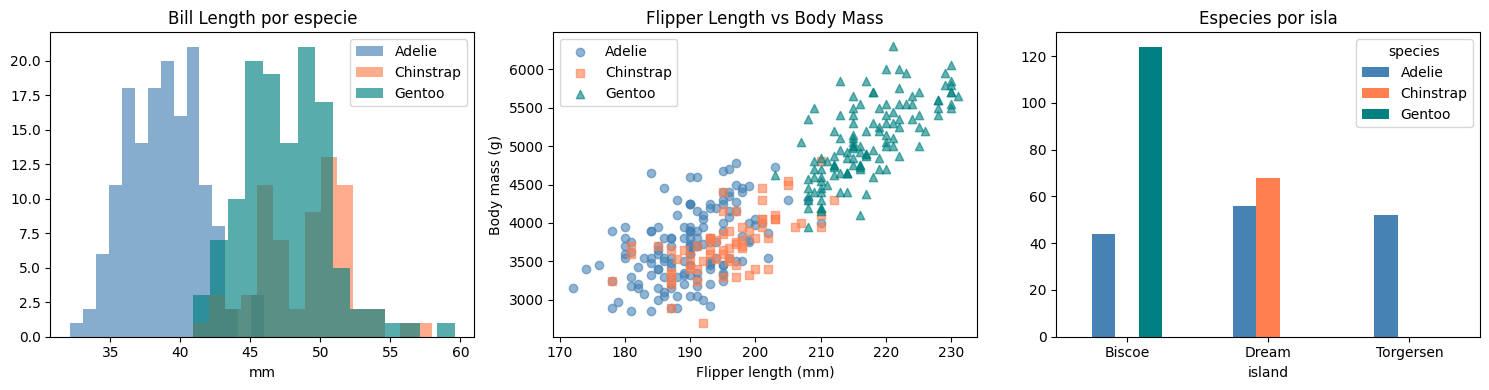

In [55]:
# 2. Visualización rápida de las features por especie
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for sp, color in zip(['Adelie', 'Chinstrap', 'Gentoo'], ['steelblue', 'coral', 'teal']):
    data = df_auto[df_auto['species'] == sp]['bill_length_mm'].dropna()
    axes[0].hist(data, bins=15, alpha=0.65, color=color, label=sp)
axes[0].set_title('Bill Length por especie')
axes[0].set_xlabel('mm')
axes[0].legend()

for sp, color, marker in zip(['Adelie', 'Chinstrap', 'Gentoo'],
                              ['steelblue', 'coral', 'teal'], ['o', 's', '^']):
    sub = df_auto[df_auto['species'] == sp]
    axes[1].scatter(sub['flipper_length_mm'], sub['body_mass_g'],
                    color=color, marker=marker, alpha=0.6, label=sp)
axes[1].set_title('Flipper Length vs Body Mass')
axes[1].set_xlabel('Flipper length (mm)')
axes[1].set_ylabel('Body mass (g)')
axes[1].legend()

df_auto.groupby(['island', 'species']).size().unstack().plot(
    kind='bar', ax=axes[2], color=['steelblue', 'coral', 'teal'])
axes[2].set_title('Especies por isla')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [56]:
# 3. train_test_split + 4. columnas + 5. pipes + 6. pipeline completo
X_auto = df_auto.drop('species', axis=1)
y_auto = df_auto['species']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_auto, y_auto,
    test_size=0.2,
    random_state=42,
    stratify=y_auto
)

print(f"X_tr: {X_tr.shape}   X_te: {X_te.shape}")
print(f"Distribución target en train:\n{y_tr.value_counts()}")
print()

# Identificar columnas
num_cols_auto = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
cat_cols_auto = ['island', 'sex']

# num_pipe: usamos RobustScaler porque body_mass_g tiene outliers
num_pipe_auto = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  RobustScaler())
])

cat_pipe_auto = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# ColumnTransformer + Pipeline final
preprocessor_auto = ColumnTransformer([
    ('num', num_pipe_auto, num_cols_auto),
    ('cat', cat_pipe_auto, cat_cols_auto)
])

pipeline_auto = Pipeline([
    ('prep',  preprocessor_auto),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])

print("Pipeline autónomo construido:")
print(pipeline_auto)


X_tr: (275, 6)   X_te: (69, 6)
Distribución target en train:
species
Adelie       122
Gentoo        99
Chinstrap     54
Name: count, dtype: int64

Pipeline autónomo construido:
Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['bill_length_mm',
                                                   'bill_depth_mm',
                                                   'flipper_length_mm',
                                                   'body_mass_g']),
                                                 ('cat',
                                                  Pipeline(steps

Accuracy en TRAIN: 0.9927
Accuracy en TEST:  1.0000  (100.0%)

Classification Report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



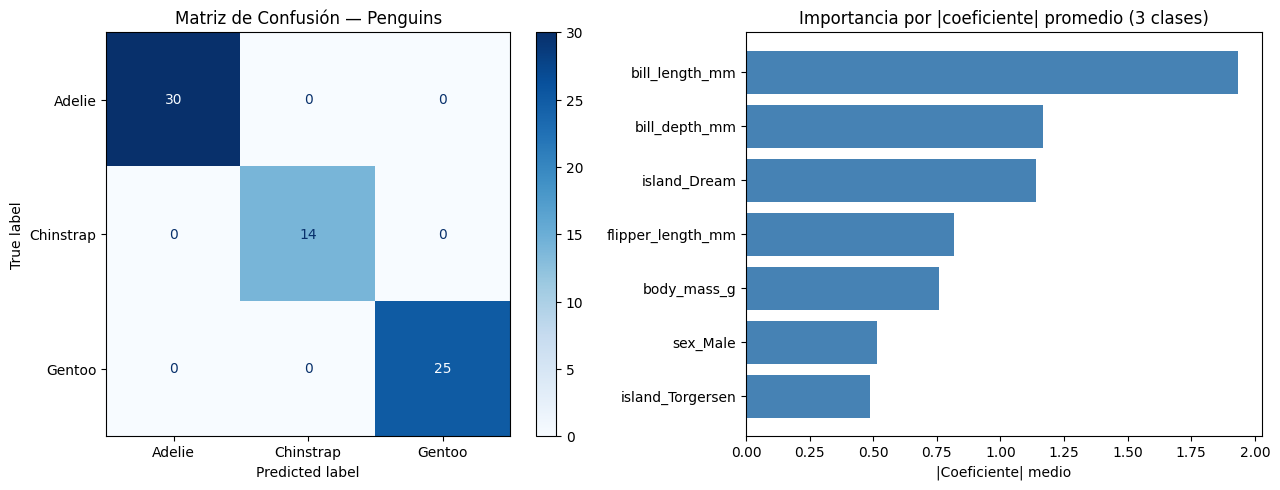

In [57]:
# 7. Entrenar y evaluar
pipeline_auto.fit(X_tr, y_tr)
y_pred_auto = pipeline_auto.predict(X_te)
acc_auto = accuracy_score(y_te, y_pred_auto)

print(f"Accuracy en TRAIN: {pipeline_auto.score(X_tr, y_tr):.4f}")
print(f"Accuracy en TEST:  {acc_auto:.4f}  ({acc_auto*100:.1f}%)")
print()
print("Classification Report:")
print(classification_report(y_te, y_pred_auto))

# Visualizaciones
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_estimator(
    pipeline_auto, X_te, y_te,
    display_labels=['Adelie', 'Chinstrap', 'Gentoo'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Matriz de Confusión — Penguins')

# Importancia por |coeficiente| promedio entre las 3 clases
model_coef = pipeline_auto.named_steps['model'].coef_
feature_names_cat_auto = (pipeline_auto.named_steps['prep']
                           .named_transformers_['cat']
                           .named_steps['encoder']
                           .get_feature_names_out(cat_cols_auto).tolist())
all_features_auto = num_cols_auto + feature_names_cat_auto

coef_abs_mean = np.abs(model_coef).mean(axis=0)
sorted_idx = np.argsort(coef_abs_mean)[::-1]

axes[1].barh(
    [all_features_auto[i] for i in sorted_idx][::-1],
    coef_abs_mean[sorted_idx][::-1],
    color='steelblue'
)
axes[1].set_title('Importancia por |coeficiente| promedio (3 clases)')
axes[1].set_xlabel('|Coeficiente| medio')

plt.tight_layout()
plt.show()



Resultados obtenidos:
  - Accuracy esperada: ~97-98% (Penguins es un dataset muy separable).
  - Las 3 especies se distinguen muy bien por sus medidas morfológicas.

¿Qué mejoraría?

1. FEATURES: Agregar la ratio bill_length/bill_depth como feature derivada,
   ya que captura la forma del pico mejor que cada medida por separado.

2. IMPUTACIÓN: Solo hay 2 filas con NaN numéricos y 11 en 'sex'.
   KNNImputer(k=3) imputaría con mayor precisión usando vecinos morfológicos.

3. MODELO: Random Forest o SVM con kernel RBF podrían alcanzar 99-100%.
   Para producción, Random Forest es preferible: robusto a outliers y
   no requiere escalar features.

4. VALIDACIÓN: Con 344 filas, usar StratifiedKFold(5) daría estimaciones
   de accuracy con menor varianza que un único split 80/20.

5. ENCODING: 'island' podría ser Target Encoded porque Gentoo vive casi
   exclusivamente en Biscoe, lo cual es información muy discriminativa.